In [39]:
!pip install japanize-matplotlib

In [40]:
!apt-get install -y fonts-ipafont-gothic


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-ipafont-gothic is already the newest version (00303-21ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [41]:
# ライブラリー／モジュールをインポートする
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import japanize_matplotlib
import seaborn as sns
import warnings
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='colorblind')
warnings.filterwarnings('ignore')
# 日本語の設定
mpl.rcParams['font.family'] = 'IPAPGothic'
plt.rcParams['font.family'] = 'IPAexGothic'
# 乱数シード固定（再現性のため）
np.random.seed(42)


In [42]:
from sklearn.datasets import load_wine
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['target_name'] = df['target'].map({0: 'class_0', 1: 'class_1', 2: 'class_2'})
print(f'データセット概要: {df.shape[0]} 行 × {df.shape[1]} 列')
print(f'¥n目的変数のクラス分布:¥n{df["target_name"].value_counts()}')

データセット概要: 178 行 × 15 列
¥n目的変数のクラス分布:¥ntarget_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


In [43]:
print(f'行数 × 列数: {df.shape}')


行数 × 列数: (178, 15)


In [44]:
print(f'行数 × 列数: {df.shape}')


行数 × 列数: (178, 15)


In [45]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.00,0.81,11.03,12.36,13.05,13.68,14.83
malic_acid,178.0,2.34,1.12,0.74,1.60,1.87,3.08,5.80
ash,178.0,2.37,0.27,1.36,2.21,2.36,2.56,3.23
alcalinity_of_ash,178.0,19.49,3.34,10.60,17.20,19.50,21.50,30.00
magnesium,178.0,99.74,14.28,70.00,88.00,98.00,107.00,162.00
total_phenols,178.0,2.30,0.63,0.98,1.74,2.36,2.80,3.88
flavanoids,178.0,2.03,1.00,0.34,1.20,2.13,2.88,5.08
nonflavanoid_phenols,178.0,0.36,0.12,0.13,0.27,0.34,0.44,0.66
proanthocyanins,178.0,1.59,0.57,0.41,1.25,1.56,1.95,3.58
color_intensity,178.0,5.06,2.32,1.28,3.22,4.69,6.20,13.00


In [46]:
# Step 5: 欠損値の確認
missing = df.isnull().sum()
print('欠損値のある列:', missing[missing > 0].to_dict() if missing.sum() > 0 else 'なし')

欠損値のある列: なし


In [47]:
# Step 6: ユニーク値数の確認
df.nunique()

,0
alcohol,126
malic_acid,133
ash,79
alcalinity_of_ash,63
magnesium,53
total_phenols,97
flavanoids,132
nonflavanoid_phenols,39
proanthocyanins,101
color_intensity,132


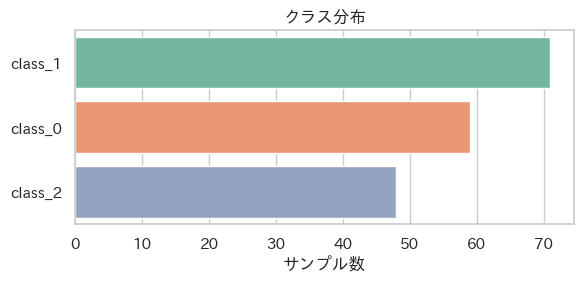

In [48]:
fig, ax = plt.subplots(figsize=(6, 3))
sns.countplot(y='target_name', data=df,
order=df['target_name'].value_counts().index,
palette='Set2', ax=ax)
ax.set_title('クラス分布')
ax.set_xlabel('サンプル数')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

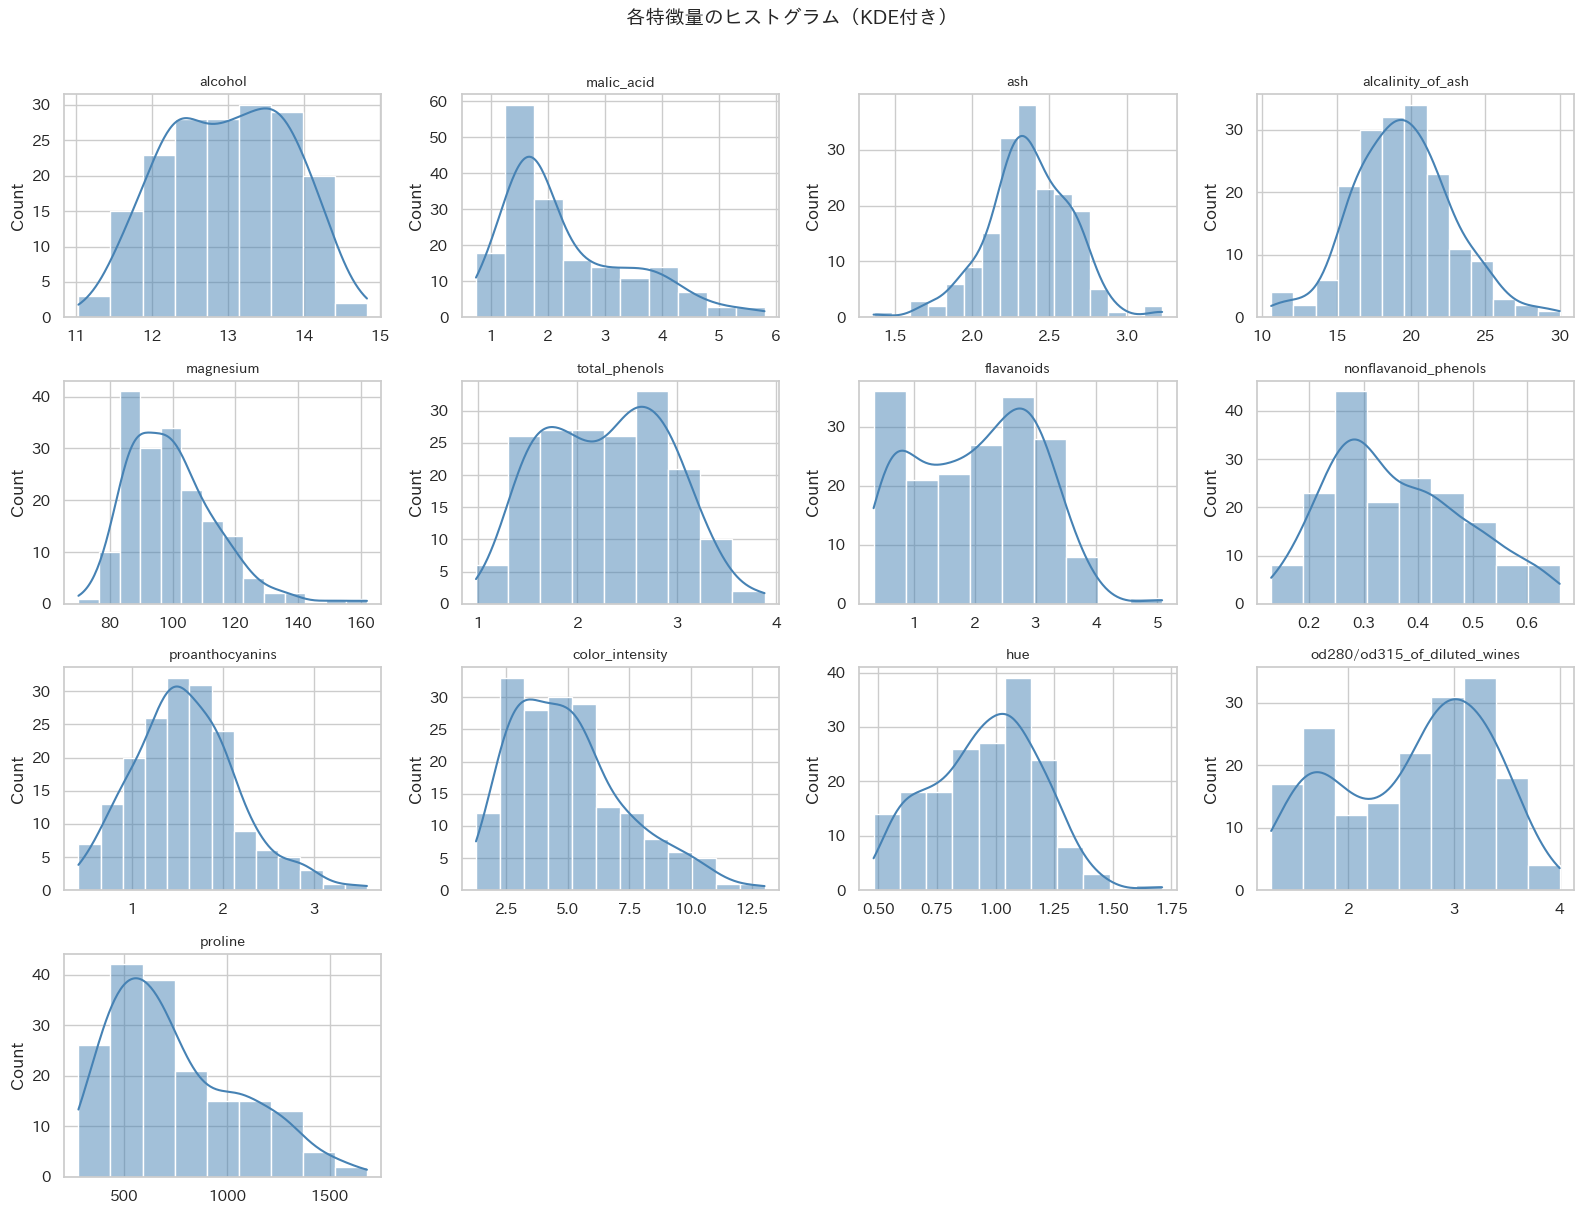

In [49]:
# 全数値列のヒストグラムを一覧表示
numeric_cols = df.select_dtypes('number').columns.drop(['target'])
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.ravel()
for i, col in enumerate(numeric_cols):
 sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
 axes[i].set_title(col, fontsize=10)
 axes[i].set_xlabel('')
# 余ったサブプロットを非表示
for j in range(len(numeric_cols), len(axes)):
 axes[j].set_visible(False)
plt.suptitle('各特徴量のヒストグラム（KDE付き）', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

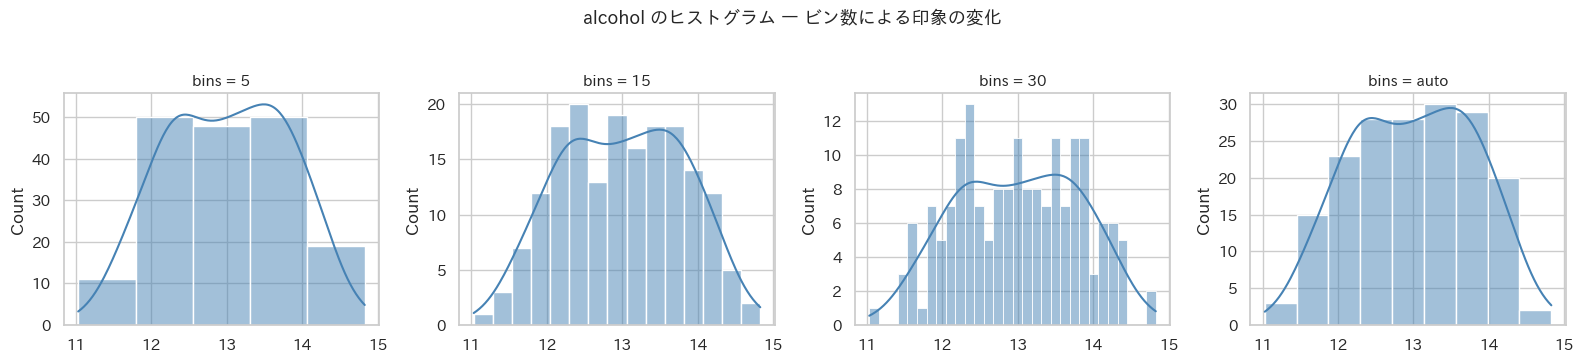

In [50]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
bin_options = [5, 15, 30, 'auto']
for ax, bins in zip(axes, bin_options):
 sns.histplot(df['alcohol'], bins=bins, kde=True, ax=ax, color='steelblue')
 ax.set_title(f'bins = {bins}', fontsize=11)
 ax.set_xlabel('')
plt.suptitle('alcohol のヒストグラム ― ビン数による印象の変化', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

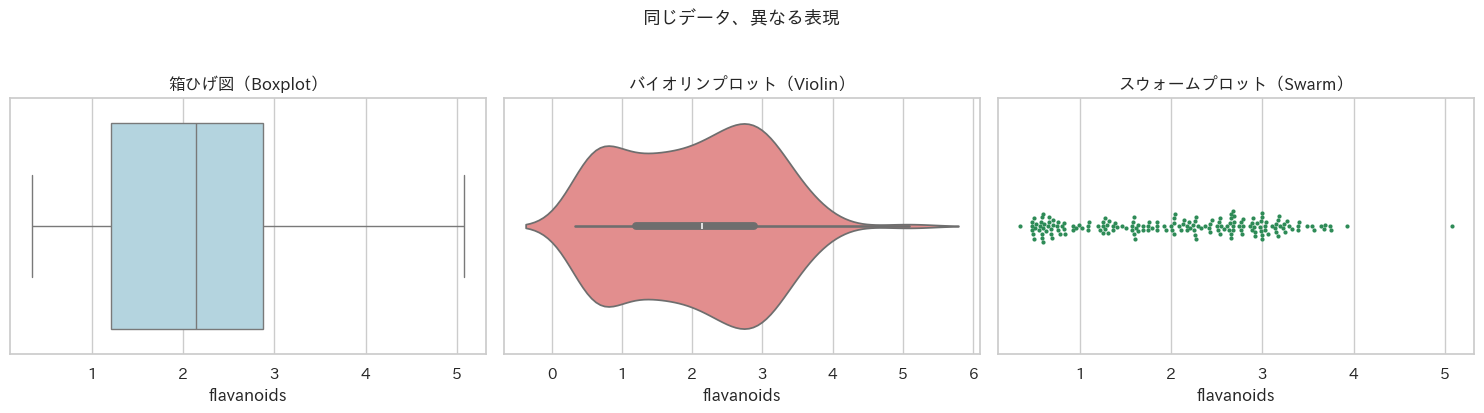

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# 箱ひげ図
sns.boxplot(x=df['flavanoids'], ax=axes[0], color='lightblue')
axes[0].set_title('箱ひげ図（Boxplot）')
# バイオリンプロット
sns.violinplot(x=df['flavanoids'], ax=axes[1], color='lightcoral')
axes[1].set_title('バイオリンプロット（Violin）')
# スウォームプロット（小規模データ向け）
sns.swarmplot(x=df['flavanoids'], ax=axes[2], color='seagreen', size=3)
axes[2].set_title('スウォームプロット（Swarm）')
plt.suptitle('同じデータ、異なる表現', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()


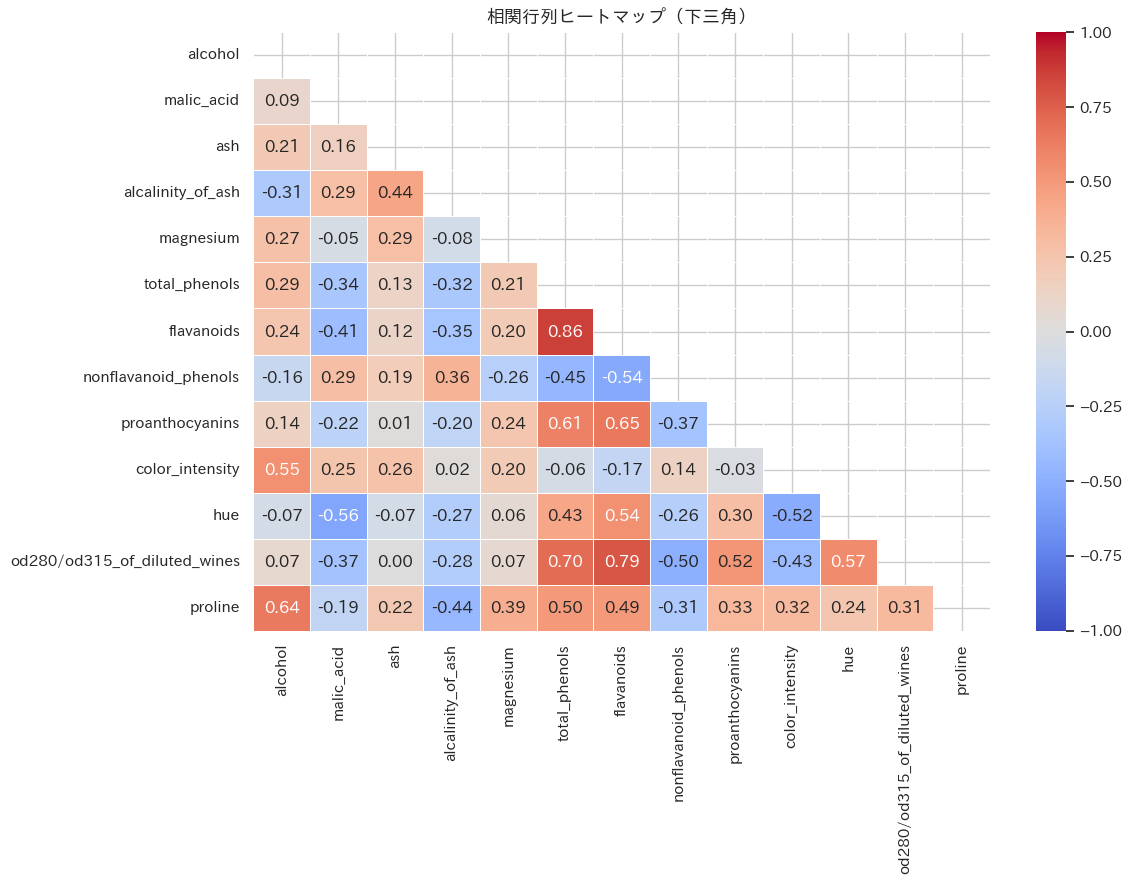

In [52]:
corr = df[numeric_cols].corr()
# マスクで上三角を隠す（冗長な情報を排除）
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
cmap='coolwarm', center=0, vmin=-1, vmax=1,
linewidths=0.5, ax=ax)
ax.set_title('相関行列ヒートマップ（下三角）', fontsize=13)
plt.tight_layout()
plt.show()

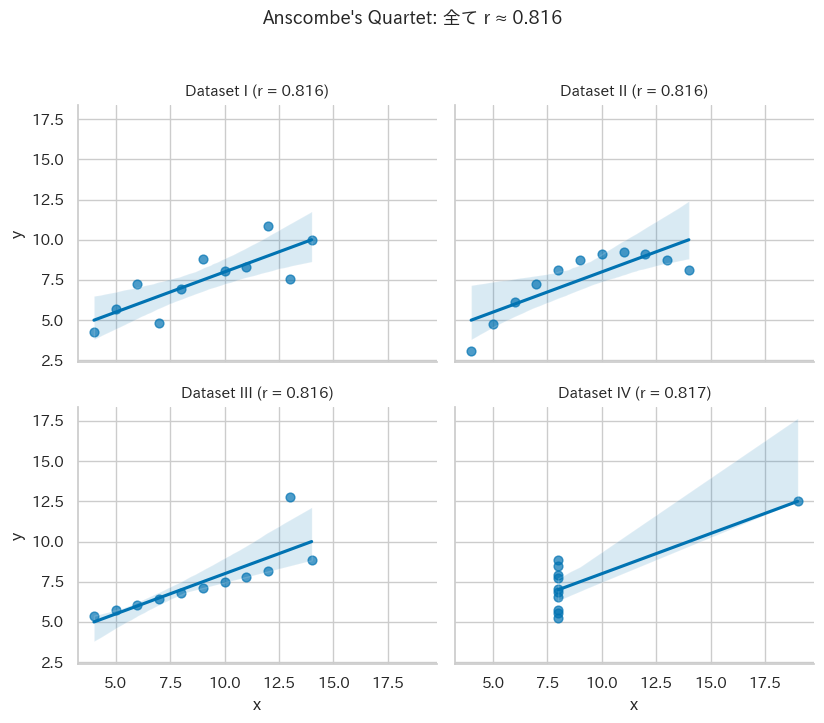

In [53]:
anscombe = sns.load_dataset('anscombe')
g = sns.lmplot(x='x', y='y', col='dataset', data=anscombe,
 col_wrap=2, height=3.5, aspect=1.2,
 scatter_kws={'s': 40, 'alpha': 0.7})
# 各データセットの相関係数をタイトルに表示
for ax, ds in zip(g.axes.ravel(), ['I', 'II', 'III', 'IV']):
 subset = anscombe[anscombe['dataset'] == ds]
 r = subset['x'].corr(subset['y'])
 ax.set_title(f'Dataset {ds} (r = {r:.3f})', fontsize=11)
plt.suptitle("Anscombe's Quartet: 全て r ≈ 0.816", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()


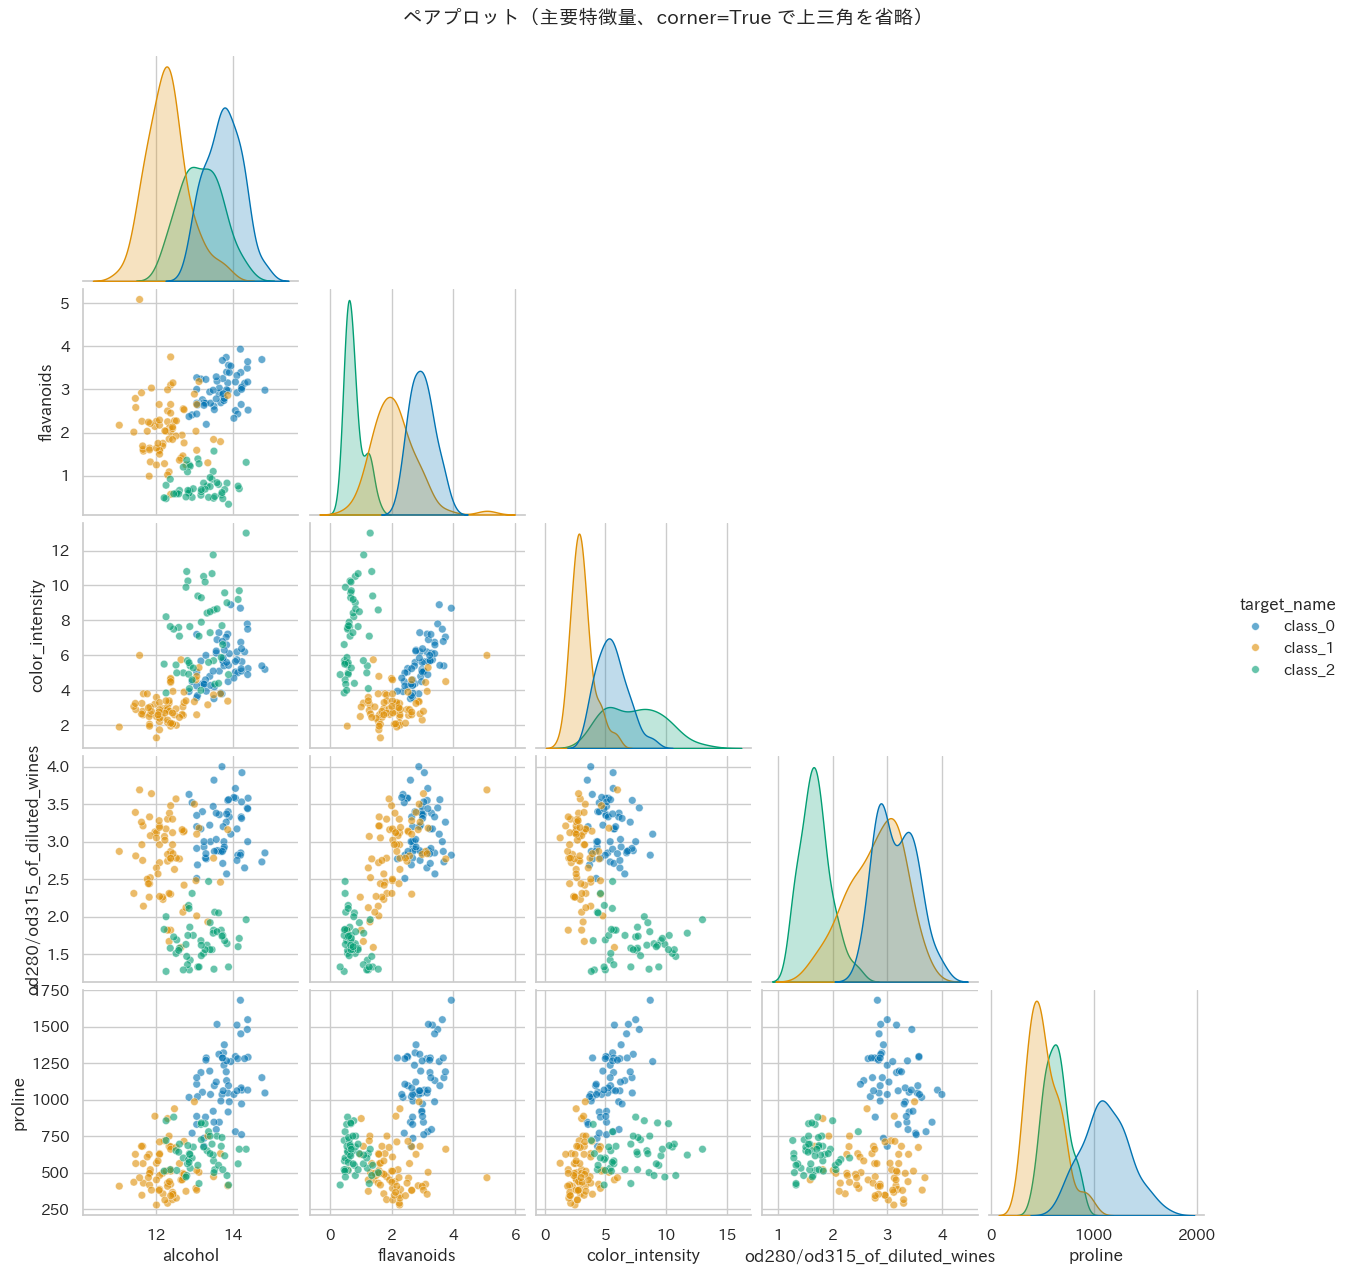

In [54]:
# 列数が多いので、代表的な特徴量を選択
selected_features = ['alcohol', 'flavanoids', 'color_intensity',
 'od280/od315_of_diluted_wines', 'proline']
sns.pairplot(df[selected_features + ['target_name']],
 hue='target_name', diag_kind='kde',
 plot_kws={'alpha': 0.6, 's': 30},
 corner=True)
plt.suptitle('ペアプロット（主要特徴量、corner=True で上三角を省略）',
 fontsize=14, y=1.02)
plt.show()

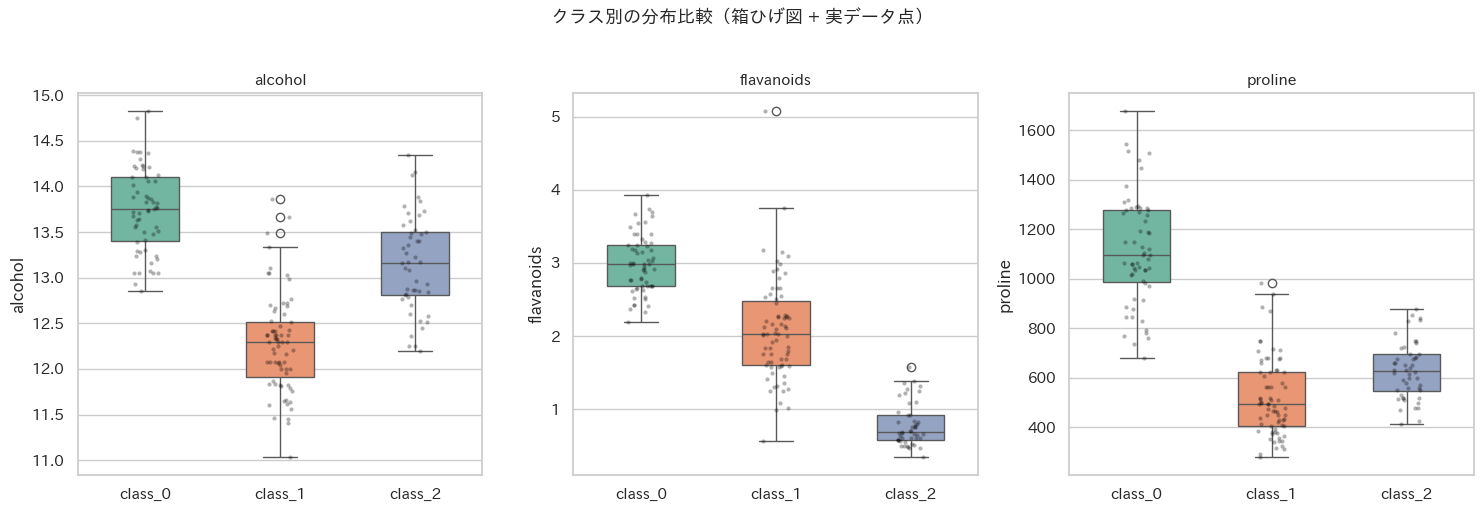

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['alcohol', 'flavanoids', 'proline']):
 sns.boxplot(x='target_name', y=col, data=df, ax=ax,
 palette='Set2', width=0.5)
 sns.stripplot(x='target_name', y=col, data=df, ax=ax,
 color='black', alpha=0.3, size=3)
 ax.set_xlabel('')
 ax.set_title(col, fontsize=11)
plt.suptitle('クラス別の分布比較（箱ひげ図 + 実データ点）', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [56]:
import missingno as msno
# 欠損データの作成（デモ用）
df_missing = df.copy()
n = len(df_missing)
# パターン1: ランダム欠損（MCAR）
df_missing.loc[np.random.choice(n, 20, replace=False), 'alcohol'] = np.nan
# パターン2: 条件付き欠損（MAR） ― prolineが低い時にmagnesiumが欠損しやすい
low_proline_idx = df_missing[df_missing['proline'] < df_missing['proline'].median()].index
df_missing.loc[np.random.choice(low_proline_idx, 25, replace=False), 'magnesium'] = np.nan
# パターン3: 共起欠損 ― 2列が同時に欠損（同じ測定プロセスの障害を模擬）
shared_idx = np.random.choice(n, 15, replace=False)
df_missing.loc[shared_idx, 'ash'] = np.nan
df_missing.loc[shared_idx, 'alcalinity_of_ash'] = np.nan
print('欠損率 (%):')
print((df_missing.isnull().sum() / n * 100).round(1).to_string())

欠損率 (%):
alcohol                         11.2
malic_acid                       0.0
ash                              8.4
alcalinity_of_ash                8.4
magnesium                       14.0
total_phenols                    0.0
flavanoids                       0.0
nonflavanoid_phenols             0.0
proanthocyanins                  0.0
color_intensity                  0.0
hue                              0.0
od280/od315_of_diluted_wines     0.0
proline                          0.0
target                           0.0
target_name                      0.0


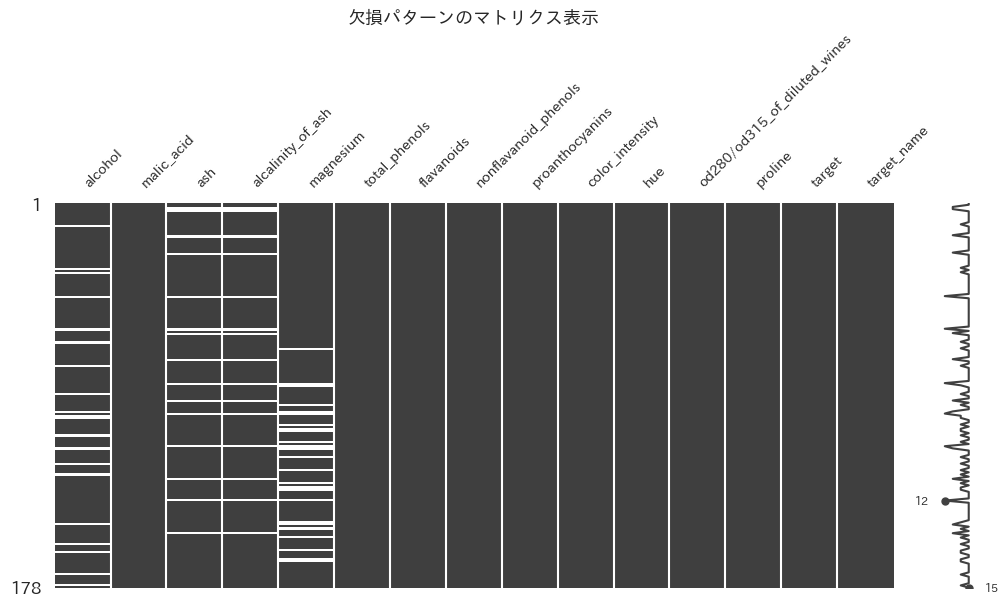

In [57]:
# 欠損パターンの全体像
msno.matrix(df_missing, figsize=(12, 5), fontsize=10)
plt.title('欠損パターンのマトリクス表示', fontsize=13)
plt.show()

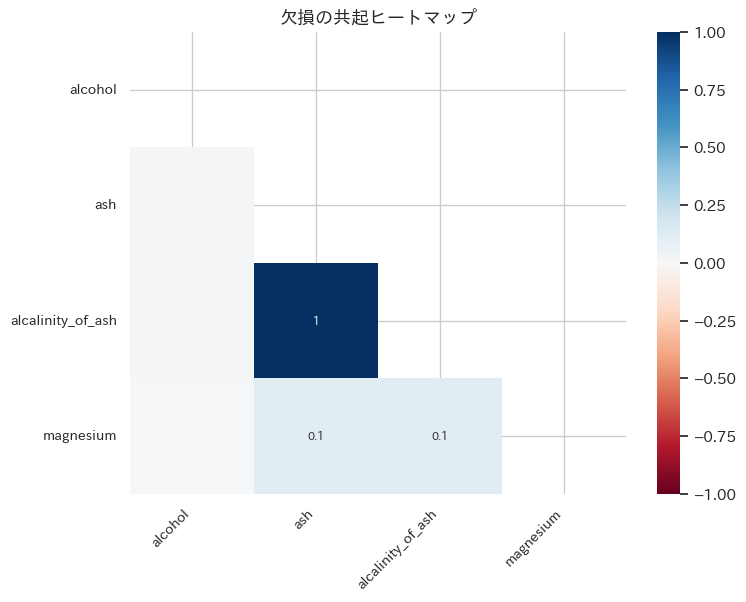

In [58]:
# 欠損の共起関係
msno.heatmap(df_missing, figsize=(8, 6), fontsize=10)
plt.title('欠損の共起ヒートマップ', fontsize=13)
plt.show()


In [59]:
!pip install ydata-profiling


In [60]:
from ydata_profiling import ProfileReport
# 軽量モードで生成（時間短縮のため minimal=True）
profile = ProfileReport(df, title='Wine Dataset EDA Report', explorative=True, minimal=True)
profile.to_notebook_iframe()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:00<00:00, 100.84it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]